# Body Segmentation

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

In video production, for example, in weather forecasts, we often need to cut out a human image from camera and place it on top of some other footage. This is typically done using **chroma key** techniques, when a human is filmed in front of a uniform color background, which is then removed. In this lab, we will train a neural network model to cut out the human silhouette.

We will be using [Segmentation Full Body MADS Dataset](https://www.kaggle.com/datasets/tapakah68/segmentation-full-body-mads-dataset) from Kaggle. Download the dataset manually from Kaggle and unzip in into current directory.

In [14]:
dataset_path = 'dataset'

import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
from PIL import Image

/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/li016390/miniforge3/envs/ai4beg/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Othe

Let's see how images in the dataset look like:

In [12]:
img_path = os.path.join(dataset_path,'images')
mask_path = os.path.join(dataset_path,'masks')

fnames = os.listdir(img_path)

def load_image(img_name):
    img = plt.imread(os.path.join(img_path,img_name))
    mask = plt.imread(os.path.join(mask_path,img_name))
    return img,mask

(-0.5, 511.5, 383.5, -0.5)

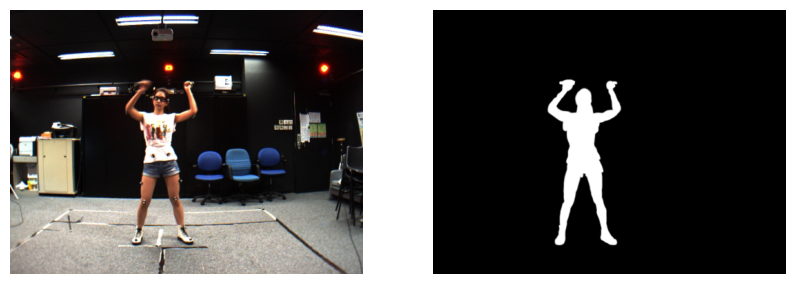

In [13]:
img, mask = load_image(fnames[5])

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img)
ax[1].imshow(mask)
ax[0].axis('off')
ax[1].axis('off')

In [15]:
class BodySegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.fnames = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.fnames[idx])
        mask_path = os.path.join(self.mask_dir, self.fnames[idx])
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
        mask = (mask > 0).float()  # Binary mask
        return image, mask

In [16]:
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

dataset = BodySegmentationDataset(img_path, mask_path, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [17]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        b = self.bottleneck(p2)
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))
        out = self.final(d1)
        return torch.sigmoid(out)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 1/10, Loss: 0.2678
Epoch 2/10, Loss: 0.1843
Epoch 3/10, Loss: 0.1630
Epoch 4/10, Loss: 0.1526
Epoch 5/10, Loss: 0.1195
Epoch 6/10, Loss: 0.1131
Epoch 7/10, Loss: 0.1033
Epoch 8/10, Loss: 0.0838
Epoch 9/10, Loss: 0.0711
Epoch 10/10, Loss: 0.0654


Pixel-wise accuracy on validation set: 0.9863


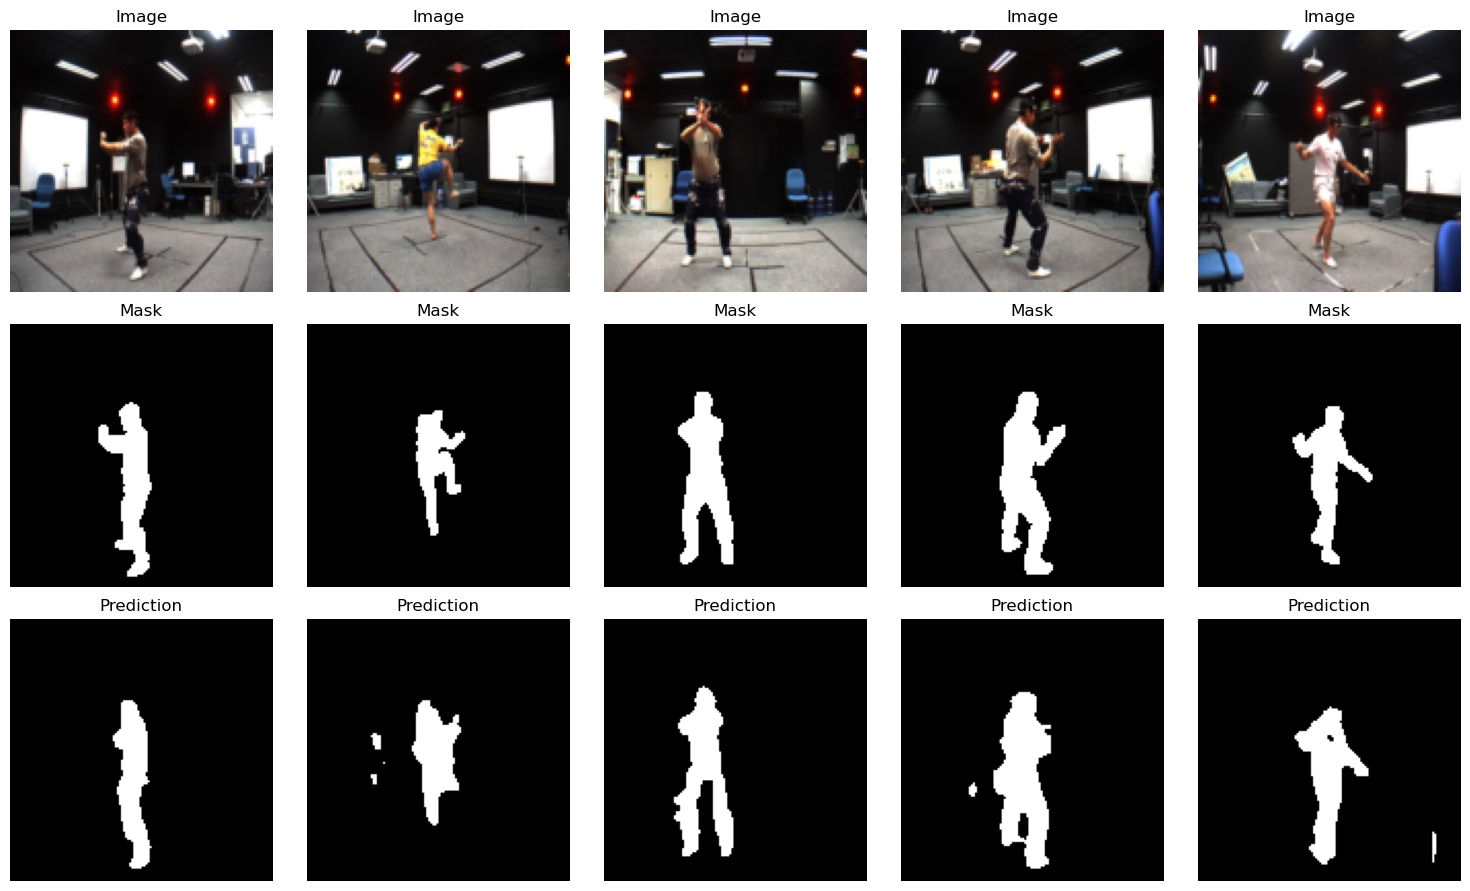

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        outputs = model(images)
        preds = (outputs > 0.5).float()
        correct += (preds == masks).sum().item()
        total += masks.numel()
accuracy = correct / total
print(f"Pixel-wise accuracy on validation set: {accuracy:.4f}")

images, masks = next(iter(val_loader))
images = images.to(device)
outputs = model(images)
preds = outputs.detach().cpu().numpy() > 0.5  

fig, axs = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    axs[0, i].imshow(np.transpose(images[i].cpu().numpy(), (1,2,0)))
    axs[0, i].set_title("Image")
    axs[1, i].imshow(masks[i][0], cmap='gray')
    axs[1, i].set_title("Mask")
    axs[2, i].imshow(preds[i][0], cmap='gray')
    axs[2, i].set_title("Prediction")
    for j in range(3):
        axs[j, i].axis('off')
plt.tight_layout()
plt.show()